In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bloox2/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [ ]:
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# 1. Configuration & Path Setup
# Updated dataset download path to match the active kagglehub cache path
DATASET_DIR = "/kaggle/input/plantvillage-dataset/Plant_leave_diseases_dataset_without_augmentation"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

# RAM Optimization: Limit classes to Corn, Potato, and Tomato
SELECTED_CLASSES = [
    "Corn___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn___Common_rust",
    "Corn___Northern_Leaf_Blight",
    "Corn___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy"
]

print("Dataset path:", DATASET_DIR)
print("Loading specified classes:", SELECTED_CLASSES)

# 2. Data Pipeline Setup (tf.data)
print("Loading training dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_names=SELECTED_CLASSES
)

print("Loading validation dataset...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_names=SELECTED_CLASSES
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Loaded {num_classes} classes: {class_names}")

# Save class names to JSON for mobile app integration
with open("class_names.json", "w") as f:
    json.dump(class_names, f)
print("Saved class_names.json successfully.")

# Optimize pipeline: Using memory cache and prefetching directly
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 3. Model Architecture (Transfer Learning with ResNet50)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

base_model = ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model weights
base_model.trainable = False

# Assemble full model
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name="CropDisease_ResNet50")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 4. Model Training
print("Starting model training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# 5. TFLite Conversion and Quantization
print("Converting model to TFLite format...")
keras_model_path = "crop_disease_model.keras"
model.save(keras_model_path)

# Convert using Float16 quantization to optimize size for mobile
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_model_path = "crop_disease_model.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print(f"Model successfully converted and saved to {tflite_model_path}")

# 6. Download files automatically in Colab
from google.colab import files
try:
    files.download(tflite_model_path)
    files.download("class_names.json")
except Exception as e:
    print("File download was not completed. You can download them manually from the sidebar:", e)

Dataset path: /kaggle/input/plantvillage-dataset/Plant_leave_diseases_dataset_without_augmentation
Loading specified classes: ['Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
Loading training dataset...
Found 12631 files belonging to 11 classes.
Using 10105 files for training.
Loading validation dataset...
Found 12631 files belonging to 11 classes.
Using 2526 files for validation.
Loaded 11 classes: ['Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
Saved class_names.json successfully.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0

Model: "CropDisease_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 11)        │     22,539 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,610,251 (90.07 MB)

 Trainable params: 22,539 (88.04 KB)

...

Starting model training...
Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 91s 179ms/step - accuracy: 0.8235 - loss: 0.5249 - val_accuracy: 0.9014 - val_loss: 0.2875
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step - accuracy: 0.9188 - loss: 0.2314 - val_accuracy: 0.9026 - val_loss: 0.2566
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step - accuracy: 0.9271 - loss: 0.1999 - val_accuracy: 0.9283 - val_loss: 0.2134
Epoch 4/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step - accuracy: 0.9406 - loss: 0.1728 - val_accuracy: 0.9192 - val_loss: 0.2346
Epoch 5/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step - accuracy: 0.9498 - loss: 0.1537 - val_accuracy: 0.9319 - val_loss: 0.1976
Epoch 6/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step - accuracy: 0.9492 - loss: 0.1469 - val_accuracy: 0.9394 - val_loss: 0.1776
Epoch 7/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step - accuracy: 0.9479 - loss: 0.1436 - val_accuracy: 0.9390 - val_loss: 0.1686
Epoch 8/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step -

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Evaluating validation set predictions...

--- Classification Report ---
                                            precision    recall  f1-score   support

Corn___Cercospora_leaf_spot Gray_leaf_spot       0.66      0.97      0.78       102
                        Corn___Common_rust       0.99      1.00      0.99       226
               Corn___Northern_Leaf_Blight       0.98      0.74      0.84       207
                            Corn___healthy       1.00      1.00      1.00       218
                     Potato___Early_blight       0.98      1.00      0.99       218
                      Potato___Late_blight       0.97      0.97      0.97       182
                          Potato___healthy       0.94      1.00      0.97        32
                   Tomato___Bacterial_spot       1.00      0.94      0.97       429
                     Tomato___Early_blight       0.94      0.78      0.85       191
                      Tomato___Late_blight       0.92      0.96      0.94       394
   

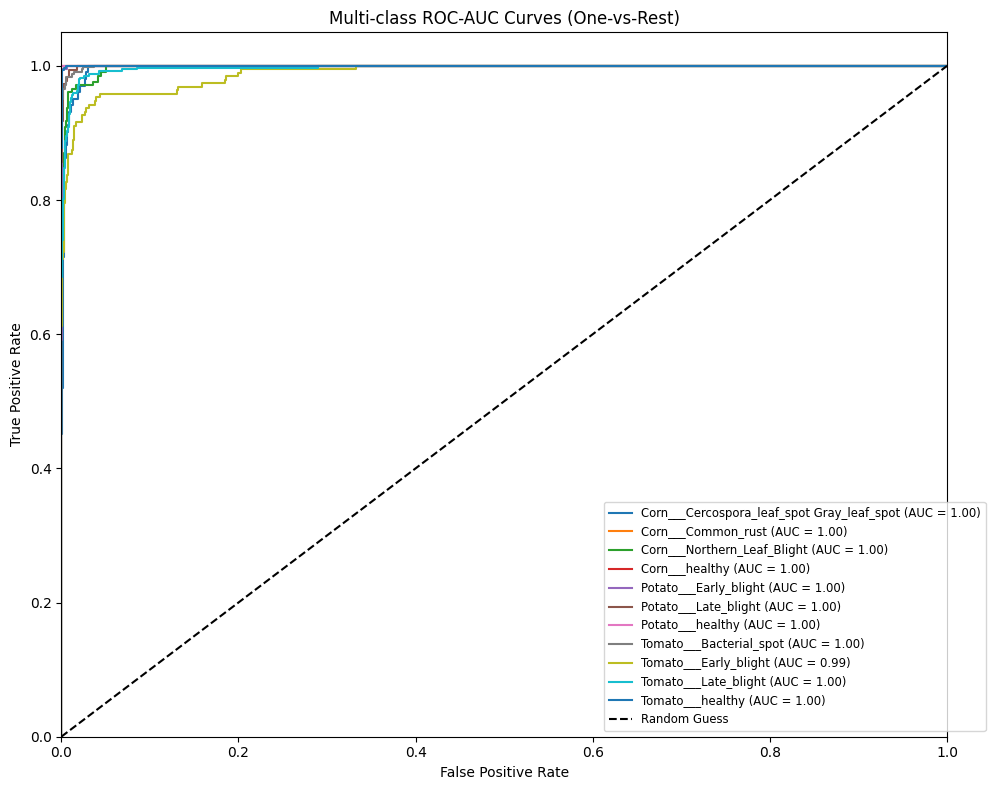


Displaying validation samples with predictions...


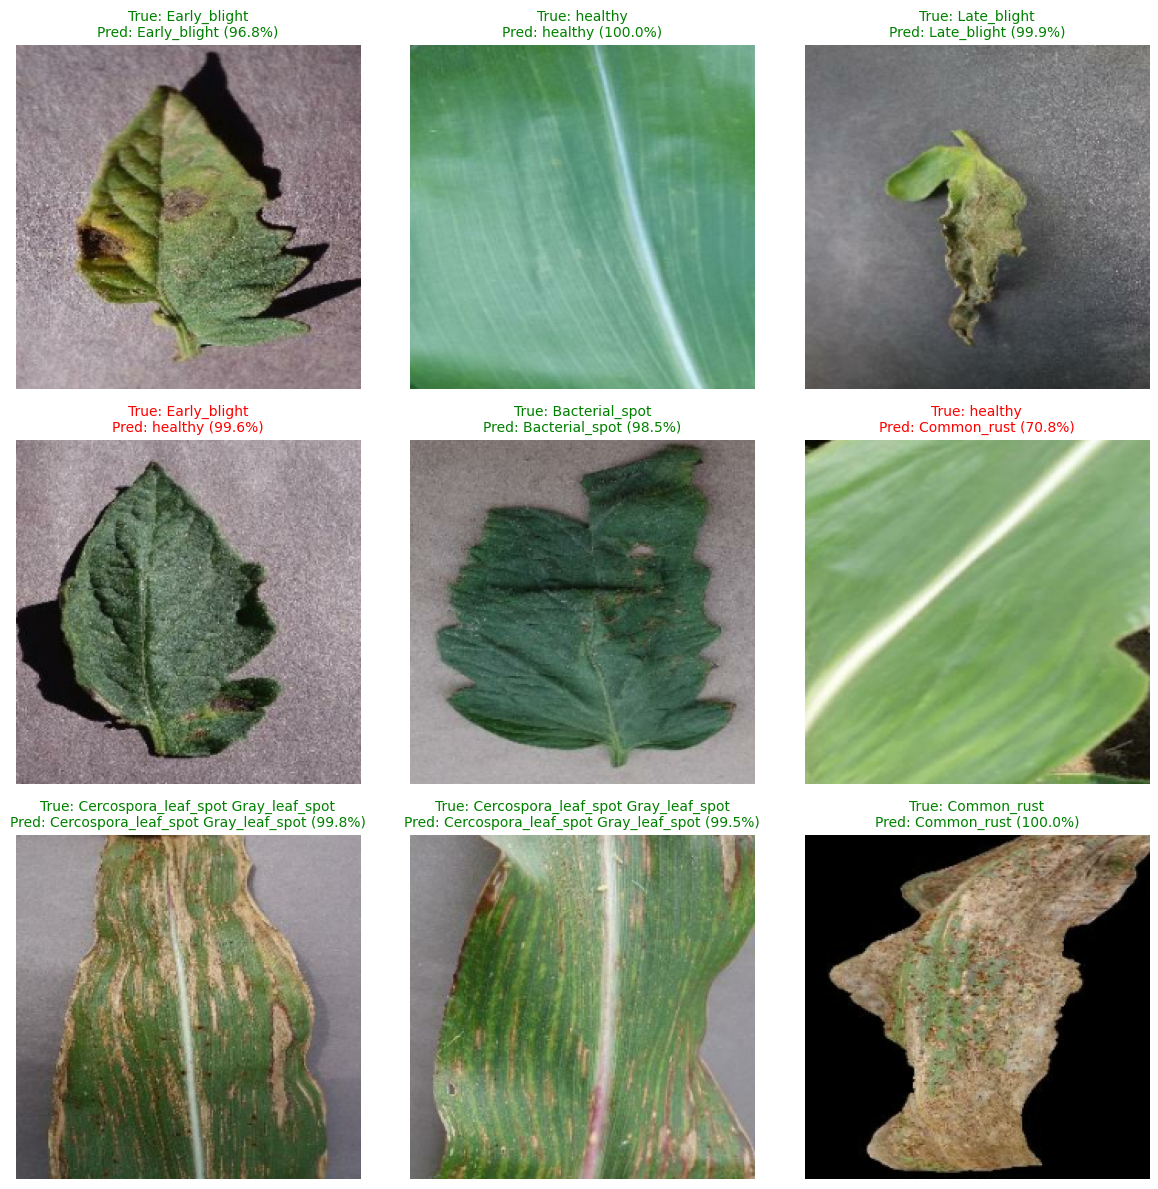

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Gather all true labels and predictions from validation set
print("Evaluating validation set predictions...")
y_true = []
y_pred_probs = []

# Iterate over the validation dataset to collect ground truth and model predictions
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Calculate and print performance metrics
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Calculate overall ROC-AUC Score (One-vs-Rest)
y_true_binarized = label_binarize(y_true, classes=range(num_classes))
macro_roc_auc = roc_auc_score(y_true_binarized, y_pred_probs, multi_class="ovr", average="macro")
print(f"Macro-average ROC-AUC Score: {macro_roc_auc:.4f}")

# 3. Plot ROC-AUC Curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC-AUC Curves (One-vs-Rest)')
plt.legend(loc="lower right", bbox_to_anchor=(1.05, 0), fontsize='small')
plt.tight_layout()
plt.show()

# 4. Display sample predictions with validation images
print("\nDisplaying validation samples with predictions...")
plt.figure(figsize=(12, 12))
# Get one batch of validation images
for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Scale images back if they were preprocessed or keep them raw for visualization
        # ResNet preprocess scales to [-127.5, 127.5] approx or shifts values; normalized display here:
        img_display = images[i].numpy().astype("uint8")

        true_idx = labels[i].numpy()
        pred_idx = np.argmax(preds[i])
        confidence = preds[i][pred_idx] * 100

        true_label = class_names[true_idx].split("___")[-1]
        pred_label = class_names[pred_idx].split("___")[-1]

        title_color = 'green' if true_idx == pred_idx else 'red'

        plt.imshow(img_display)
        plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", color=title_color, fontsize=10)
        plt.axis("off")
plt.tight_layout()
plt.show()